IMPORTACIÓN DE LIBRERÍAS + CARGA DE DATOS


## 1. Importación de librerías

En este apartado se importan las librerías necesarias para:
- Manipulación y análisis de datos
- Visualización gráfica
- Modelos de aprendizaje no supervisado (K-Means)
- Modelos supervisados de clasificación
- Evaluación y guardado de modelos


In [67]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

sns.set_context("notebook")
pd.set_option("display.max_columns", 200)




## 2. Carga del conjunto de datos

Se carga el conjunto de datos **California Housing**, que contiene información socioeconómica y geográfica de California.
Este dataset será la base para realizar el sistema de agrupación de viviendas.


In [68]:
# ## 1. Carga del dataset


df = pd.read_csv("../data/raw/internal-link(7).csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Inspección inicial de los datos

Se realiza una revisión básica del conjunto de datos para conocer:
- Dimensiones del dataset
- Nombres de las columnas
- Posibles valores nulos
- Estadísticas descriptivas iniciales


In [69]:
print("Shape:", df.shape)
print("\nColumnas:\n", df.columns)

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(20))

df[["Latitude", "Longitude", "MedInc"]].describe()


Shape: (20640, 9)

Columnas:
 Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


Series([], dtype: int64)

,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


## 4. Selección de variables relevantes

Siguiendo las instrucciones del ejercicio, se seleccionan únicamente las variables:
- Latitude
- Longitude
- MedInc

Estas variables serán utilizadas para el proceso de clustering.


In [70]:
X = df[["Latitude", "Longitude", "MedInc"]].copy()
X = X.dropna()

X.head(), X.shape


(   Latitude  Longitude  MedInc
 0     37.88    -122.23  8.3252
 1     37.86    -122.22  8.3014
 2     37.85    -122.24  7.2574
 3     37.85    -122.25  5.6431
 4     37.85    -122.25  3.8462,
 (20640, 3))

## 5. Análisis exploratorio de datos (EDA)

Se analizan las distribuciones de las variables seleccionadas y su correlación.
Este paso permite comprender mejor la escala y el comportamiento de los datos antes de aplicar modelos de aprendizaje automático.


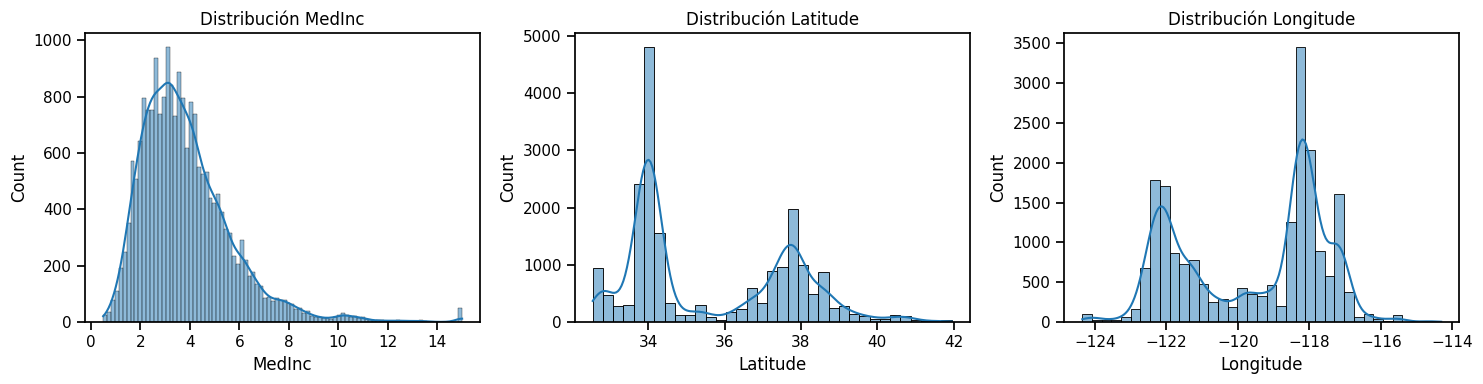

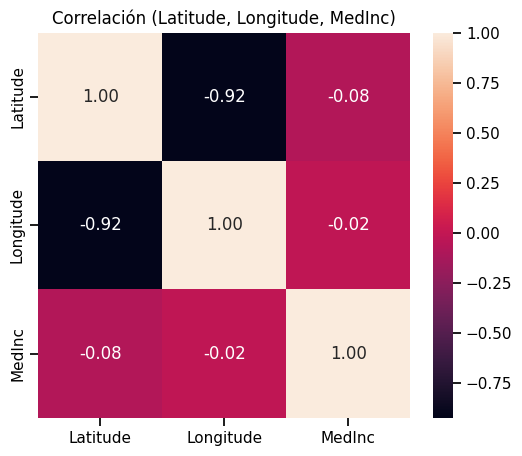

In [71]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(X["MedInc"], ax=ax[0], kde=True)
ax[0].set_title("Distribución MedInc")

sns.histplot(X["Latitude"], ax=ax[1], kde=True)
ax[1].set_title("Distribución Latitude")

sns.histplot(X["Longitude"], ax=ax[2], kde=True)
ax[2].set_title("Distribución Longitude")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(X.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlación (Latitude, Longitude, MedInc)")
plt.show()


## 6. División en conjuntos de entrenamiento y prueba

El conjunto de datos se divide en:
- Conjunto de entrenamiento (80%)
- Conjunto de prueba (20%)

Aunque el modelo es no supervisado, esta división permite evaluar posteriormente la capacidad de generalización del clustering.


In [72]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (16512, 3)
Test : (4128, 3)


## 7. Evaluación del número de clusters

Se calcula el **silhouette score** para distintos valores de K con el objetivo de evaluar la calidad del clustering.
Aunque el enunciado fija K=6, este análisis adicional permite justificar dicha elección.


In [ ]:
Ks = range(2, 11)
scores = []

for k in Ks:
    tmp_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=k, n_init=10, random_state=42))
    ])
    tmp_pipe.fit(X_train)
    
    X_train_scaled = tmp_pipe.named_steps["scaler"].transform(X_train)
    labels = tmp_pipe.named_steps["kmeans"].labels_
    
    scores.append(silhouette_score(X_train_scaled, labels))

plt.figure(figsize=(7,4))
plt.plot(list(Ks), scores, marker="o")
plt.xticks(list(Ks))
plt.title("Silhouette score (train) vs K")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.show()

print("Silhouette para K=6:", scores[list(Ks).index(6)])


## 8. Entrenamiento del modelo K-Means

Se entrena un modelo K-Means con **6 clusters**, aplicando previamente una normalización de las variables.
El modelo se ajusta únicamente con el conjunto de entrenamiento.


In [ ]:
kmeans_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=6, n_init=10, random_state=42))
])

kmeans_pipe.fit(X_train)


,steps,"[('scaler', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,6
,init,'k-means++'
,n_init,10
,max_iter,300


## 9. Asignación de clusters al conjunto de entrenamiento

Se añade una nueva columna llamada **cluster** al conjunto de entrenamiento, que indica el grupo asignado por el modelo K-Means a cada vivienda.


In [ ]:
train_df = X_train.copy()
train_df["cluster"] = kmeans_pipe.named_steps["kmeans"].labels_
train_df["cluster"] = train_df["cluster"].astype("category")

train_df.head()


,Latitude,Longitude,MedInc,cluster
14196,32.71,-117.03,3.2596,5
8267,33.77,-118.16,3.8125,5
17445,34.66,-120.48,4.1563,0
14265,32.69,-117.11,1.9425,5
2271,36.78,-119.80,3.5542,0


## 10. Visualización de los clusters

Se representa gráficamente la distribución de los clusters en función de la longitud y la latitud.
Esta visualización permite identificar patrones geográficos en la agrupación de las viviendas.


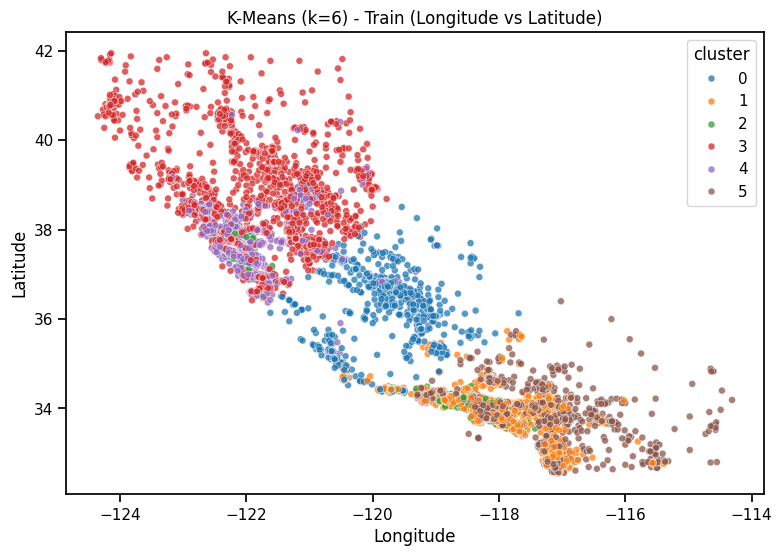

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=train_df,
    x="Longitude", y="Latitude",
    hue="cluster",
    s=25, alpha=0.75
)
plt.title("K-Means (k=6) - Train (Longitude vs Latitude)")
plt.show()


## 11. Visualización avanzada de los clusters

Se realizan visualizaciones adicionales incorporando el ingreso medio (MedInc).
Estas gráficas permiten analizar cómo influye el nivel de ingresos en la formación de los clusters.


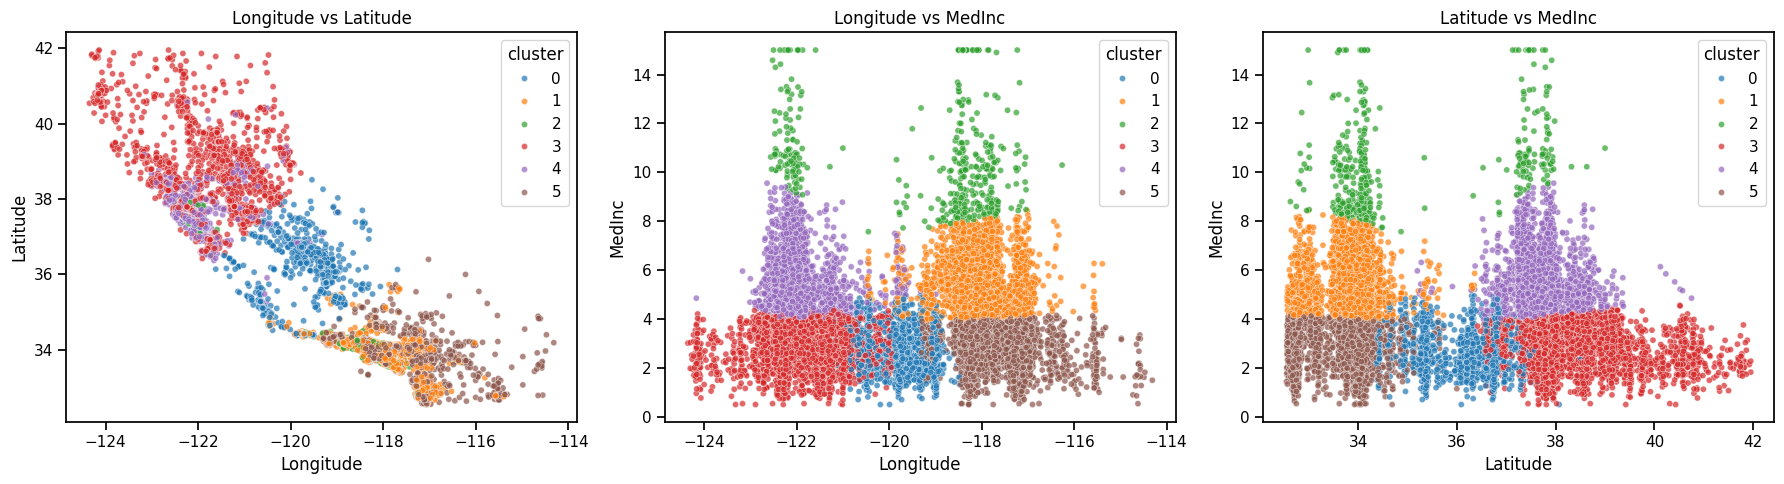

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(ax=ax[0], data=train_df, x="Longitude", y="Latitude", hue="cluster", s=20, alpha=0.7)
ax[0].set_title("Longitude vs Latitude")

sns.scatterplot(ax=ax[1], data=train_df, x="Longitude", y="MedInc", hue="cluster", s=20, alpha=0.7)
ax[1].set_title("Longitude vs MedInc")

sns.scatterplot(ax=ax[2], data=train_df, x="Latitude", y="MedInc", hue="cluster", s=20, alpha=0.7)
ax[2].set_title("Latitude vs MedInc")

plt.tight_layout()
plt.show()


## 12. Predicción de clusters en el conjunto de prueba

Una vez entrenado el modelo, se predice el cluster correspondiente a cada observación del conjunto de prueba.
Esto permite evaluar la consistencia del modelo con datos no utilizados en el entrenamiento.


In [ ]:
test_df = X_test.copy()
test_df["cluster"] = kmeans_pipe.predict(X_test)
test_df["cluster"] = test_df["cluster"].astype("category")

test_df.head()


,Latitude,Longitude,MedInc,cluster
20046,36.06,-119.01,1.6812,0
3024,35.14,-119.46,2.5313,0
15663,37.80,-122.44,3.4801,3
20484,34.28,-118.72,5.7376,1
9814,36.62,-121.93,3.7250,3


## 13. Comparación entre entrenamiento y prueba

Se visualizan conjuntamente los datos de entrenamiento y de prueba para comprobar si los puntos del conjunto test se asignan a regiones coherentes con los clusters obtenidos.


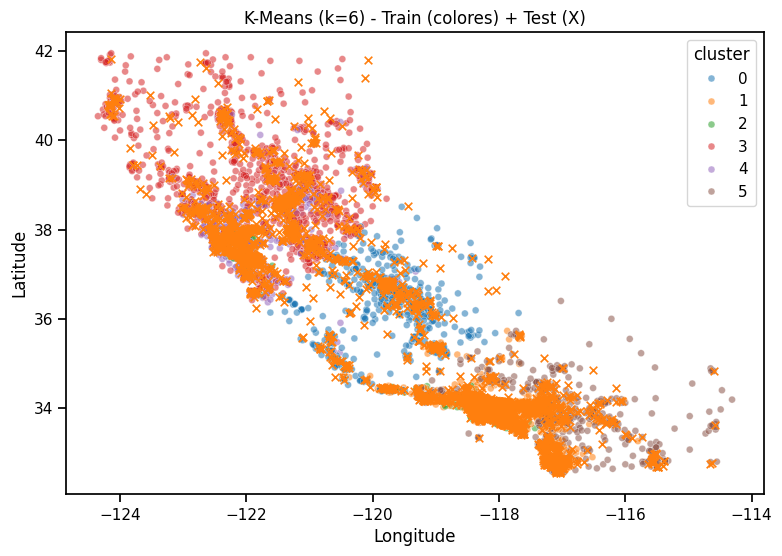

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=train_df,
    x="Longitude", y="Latitude",
    hue="cluster",
    s=25, alpha=0.55
)

plt.scatter(
    test_df["Longitude"], test_df["Latitude"],
    marker="x", s=30, linewidths=1.2
)

plt.title("K-Means (k=6) - Train (colores) + Test (X)")
plt.show()


## 14. Entrenamiento de un modelo supervisado

A partir de los clusters generados por K-Means, se entrena un modelo de clasificación supervisada.
Este enfoque permite aprender de las etiquetas generadas automáticamente por el modelo no supervisado.


In [ ]:
y_train = train_df["cluster"].astype(int)
y_test  = test_df["cluster"].astype(int)

clf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced_subsample"
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9956395348837209

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       337
           1       1.00      1.00      1.00       829
           2       1.00      0.98      0.99       112
           3       0.99      0.99      0.99       962
           4       0.99      1.00      0.99       514
           5       1.00      1.00      1.00      1374

    accuracy                           1.00      4128
   macro avg       1.00      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128


Confusion matrix:
 [[ 332    1    0    3    1    0]
 [   0  827    0    0    0    2]
 [   0    2  110    0    0    0]
 [   1    0    0  957    4    0]
 [   0    0    0    2  512    0]
 [   1    1    0    0    0 1372]]


## 15. Validación cruzada del modelo supervisado

Se aplica validación cruzada para evaluar la estabilidad y robustez del modelo de clasificación entrenado.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Etiquetas para todo X usando KMeans (pseudo-etiquetas)
y_all = kmeans_pipe.predict(X)

scores = cross_val_score(clf, X, y_all, cv=cv, scoring="accuracy")

print("CV accuracy (5 folds):", scores)
print("Mean:", scores.mean(), "Std:", scores.std())


CV accuracy (5 folds): [0.99515504 0.99297481 0.99709302 0.9934593  0.9939438 ]
Mean: 0.9945251937984496 Std: 0.0014743337262308834


## 16. Importancia de las variables

Se analiza la importancia de cada variable en el modelo supervisado, lo que permite interpretar qué factores influyen más en la asignación de clusters.


MedInc       0.536683
Latitude     0.233834
Longitude    0.229483
dtype: float64

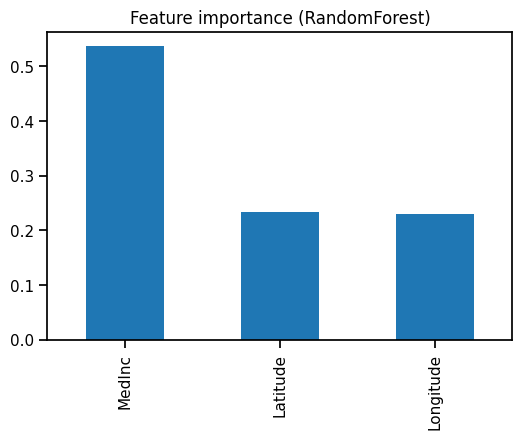

In [ ]:
importances = pd.Series(clf.feature_importances_, index=["Latitude", "Longitude", "MedInc"]).sort_values(ascending=False)
display(importances)

plt.figure(figsize=(6,4))
importances.plot(kind="bar")
plt.title("Feature importance (RandomForest)")
plt.show()


## 17. Almacenamiento de los modelos

Se guardan tanto el modelo K-Means como el modelo de clasificación supervisada para su reutilización futura.


In [ ]:
os.makedirs("models", exist_ok=True)

joblib.dump(kmeans_pipe, "models/kmeans_6clusters.pkl")
joblib.dump(clf, "models/rf_cluster_classifier.pkl")

os.listdir("models")


['arima_sales.pkl', 'rf_cluster_classifier.pkl', 'kmeans_6clusters.pkl']

Conclusiones

Se utilizó el dataset California Housing y se seleccionaron las variables Latitude, Longitude y MedInc.

Se entrenó un K-Means con k=6 sobre el conjunto de entrenamiento y se añadió la etiqueta cluster.

La visualización muestra agrupaciones coherentes geográficamente y con diferencias asociadas al ingreso medio.

Se predijeron clusters en el conjunto de prueba y se comprobó visualmente que caen en zonas compatibles con los clusters del train.

Se entrenó un modelo supervisado (RandomForest) para predecir el cluster, evaluándolo con accuracy, matriz de confusión y validación cruzada.

Se guardaron ambos modelos en la carpeta models/ para reutilización.